# Nepali music and lyrics — exploratory data analysis

Local source: `data/raw/nepali_music_lyrics/archive/Final Dataset`

This notebook audits the aligned audio/lyrics collection without reading the WAV payloads. It treats each row as an audio segment for quality analysis, then groups naturally ordered segments into song-level text documents matching the pretraining standardizer. Artist-level `metadata.csv` files are authoritative; per-song CSV/XLSX files duplicate those records and are not concatenated into the training view.

In [1]:
from collections import Counter
from pathlib import Path
import math
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
EXPECTED_COLUMNS = {"SegmentFilePath", "SegmentLength", "Lyrics"}

def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "scripts" / "build_pretraining_dataset.py").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the attentionMaps repository.")

REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "raw" / "nepali_music_lyrics" / "archive" / "Final Dataset"
assert DATA_ROOT.is_dir(), f"Dataset not found: {DATA_ROOT}"


## Inventory and canonical metadata source

Every artist directory should have exactly one consolidated `metadata.csv`. Reading both that table and each song's `_segments.csv` would ingest the same lyric/audio rows twice. XLSX files are counted for audit purposes but are not needed by this notebook.

In [2]:
all_files = [path for path in DATA_ROOT.rglob("*") if path.is_file()]
artist_dirs = sorted(path for path in DATA_ROOT.iterdir() if path.is_dir())
artist_metadata_files = sorted(DATA_ROOT.glob("*/metadata.csv"))
per_song_csv_files = sorted(DATA_ROOT.rglob("*_segments.csv"))
xlsx_files = sorted(DATA_ROOT.rglob("*.xlsx"))
extension_counts = Counter(path.suffix.lower() for path in all_files)

inventory = pd.Series({
    "artists": len(artist_dirs),
    "artist_metadata_csv_files": len(artist_metadata_files),
    "per_song_segment_csv_files": len(per_song_csv_files),
    "xlsx_files_not_required": len(xlsx_files),
    "wav_files": extension_counts[".wav"],
    "all_files": len(all_files),
})
display(inventory.to_frame("count"))

if len(artist_metadata_files) != len(artist_dirs):
    missing = [path.name for path in artist_dirs if not (path / "metadata.csv").is_file()]
    print("Artists without metadata.csv:", missing)


,count
artists,38
artist_metadata_csv_files,38
per_song_segment_csv_files,105
xlsx_files_not_required,8
wav_files,3290
all_files,3441


In [3]:
frames = []
for metadata_path in artist_metadata_files:
    frame = pd.read_csv(metadata_path)
    missing = EXPECTED_COLUMNS - set(frame.columns)
    if missing:
        raise ValueError(f"{metadata_path} is missing columns: {sorted(missing)}")
    frame = frame.copy()
    frame["artist"] = metadata_path.parent.name
    frame["segment_path"] = frame["SegmentFilePath"].fillna("").astype(str).str.replace("\\", "/", regex=False)
    frame["song"] = frame["segment_path"].map(lambda value: Path(value).parent.name)
    frame["audio_path"] = frame["segment_path"].map(lambda value: metadata_path.parent / value)
    frames.append(frame)

segments = pd.concat(frames, ignore_index=True)
segments["Lyrics"] = segments["Lyrics"].fillna("").astype(str)
segments["duration_seconds"] = pd.to_numeric(segments["SegmentLength"], errors="coerce")
segments["audio_exists"] = segments["audio_path"].map(Path.is_file)
print(f"Loaded {len(segments):,} authoritative segment rows across {segments['artist'].nunique()} artists.")
segments.head(3)


Loaded 3,310 authoritative segment rows across 38 artists.


,SegmentFilePath,SegmentLength,Lyrics,artist,segment_path,song,audio_path,duration_seconds,audio_exists
0,output/Gurans Fulyo/segment_1.wav,7.620,गुराँसै फूल्यो वनैमा,1974 A.D,output/Gurans Fulyo/segment_1.wav,Gurans Fulyo,/home/aixi/attentionMaps/data/raw/nepali_music...,7.620,True
1,output/Gurans Fulyo/segment_2.wav,6.417,मेरो मन झुल्यो तिम्रो मनैमा,1974 A.D,output/Gurans Fulyo/segment_2.wav,Gurans Fulyo,/home/aixi/attentionMaps/data/raw/nepali_music...,6.417,True
2,output/Gurans Fulyo/segment_3.wav,7.340,गुराँसै फूल्यो वनैमा,1974 A.D,output/Gurans Fulyo/segment_3.wav,Gurans Fulyo,/home/aixi/attentionMaps/data/raw/nepali_music...,7.340,True


In [4]:
# Print five reproducible lyric segments without truncation.
for number, (_, row) in enumerate(segments.sample(n=5, random_state=SEED).iterrows(), start=1):
    print("=" * 100)
    print(f"SAMPLE {number}")
    print(f"Artist: {row['artist']}")
    print(f"Song: {row['song']}")
    print(f"Audio: {row['segment_path']} ({row['duration_seconds']:.3f}s; exists={row['audio_exists']})")
    print(f"Lyrics: {row['Lyrics']}")


SAMPLE 1
Artist: 1974 A.D
Song: Parelima
Audio: output/Parelima/segment_26.wav (5.560s; exists=True)
Lyrics: परेलीमा लुकाई राख न
SAMPLE 2
Artist: Bhakta Raj Acharya
Song: Tana Mann Bachanle
Audio: output/Tana Mann Bachanle/segment_11.wav (4.570s; exists=True)
Lyrics: पसी अग्निमा स्वर्ण चम्कन्छ धेरै
SAMPLE 3
Artist: Manoj Kumar KC
Song: Harsha Ko Geet
Audio: output/Harsha Ko Geet/segment_28.wav (2.670s; exists=True)
Lyrics: Just shine like the sun
SAMPLE 4
Artist: Gyanu Rana
Song: Chyangba Hai Chyangba
Audio: output/Chyangba Hai Chyangba/segment_34.wav (2.620s; exists=True)
Lyrics: आप्पा नबनाई छोड्दैन
SAMPLE 5
Artist: Adrian Pradhan
Song: Hindda Hinddai
Audio: output/Hindda Hinddai/segment_30.wav (0.845s; exists=True)
Lyrics: 


## Segment quality, script coverage, and repeated lines

Repeated lyric rows are not automatically corrupt: choruses naturally recur. They matter for language-model weighting, so we measure them rather than silently deleting them. Romanized Nepali is measured as a distinct script pattern; the current strict Nepali-only cleaning policy removes Latin characters while retaining the Devanagari portions of mixed songs.

In [5]:
def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", unicodedata.normalize("NFC", str(text))).strip()

def devanagari_ratio(text: str) -> float:
    letters = [char for char in str(text) if unicodedata.category(char).startswith("L")]
    if not letters:
        return 0.0
    devanagari = sum(
        0x0900 <= ord(char) <= 0x097F
        or 0xA8E0 <= ord(char) <= 0xA8FF
        or 0x11B00 <= ord(char) <= 0x11B5F
        for char in letters
    )
    return devanagari / len(letters)

segments["normalized_lyrics"] = segments["Lyrics"].map(normalize_text)
segments["characters"] = segments["Lyrics"].str.len()
segments["whitespace_words"] = segments["Lyrics"].map(lambda text: len(text.split()))
segments["devanagari_ratio"] = segments["Lyrics"].map(devanagari_ratio)

quality = pd.Series({
    "segments": len(segments),
    "songs": segments[["artist", "song"]].drop_duplicates().shape[0],
    "audio_hours": segments["duration_seconds"].sum() / 3600,
    "missing_audio_files": (~segments["audio_exists"]).sum(),
    "blank_lyrics": segments["normalized_lyrics"].eq("").sum(),
    "duplicate_normalized_lines": segments["normalized_lyrics"].duplicated().sum(),
    "segments_below_80pct_devanagari": segments["devanagari_ratio"].lt(0.80).sum(),
    "fully_non_devanagari_segments": segments["devanagari_ratio"].eq(0).sum(),
})
display(quality.to_frame("value"))
display(segments[["duration_seconds", "characters", "whitespace_words", "devanagari_ratio"]].quantile([0, .25, .5, .75, .95, .99, 1]))


,value
segments,3310.000000
songs,105.000000
audio_hours,5.076568
missing_audio_files,20.000000
blank_lyrics,60.000000
duplicate_normalized_lines,1490.000000
segments_below_80pct_devanagari,279.000000
fully_non_devanagari_segments,259.000000


,duration_seconds,characters,whitespace_words,devanagari_ratio
0.00,0.00000,0.0,0.0,0.0
0.25,3.63075,18.0,3.0,1.0
0.50,5.12000,26.0,5.0,1.0
0.75,6.76000,34.0,6.0,1.0
0.95,11.13770,46.0,8.0,1.0
0.99,14.71910,57.0,10.0,1.0
1.00,35.51200,77.0,12.0,1.0


## Construct song-level pretraining documents

Segments are sorted by their numeric suffix (`segment_1`, `segment_2`, …) before joining. Repeated chorus lines remain in the song text, while the repetition metric quantifies their concentration.

In [6]:
def segment_order(path: str) -> tuple[int, str]:
    stem = Path(path).stem
    match = re.search(r"(\d+)$", stem)
    return (int(match.group(1)) if match else 10**12, stem)

song_records = []
for (artist, song), group in segments.groupby(["artist", "song"], sort=True):
    ordered = group.sort_values("segment_path", key=lambda values: values.map(segment_order))
    lines = [line for line in ordered["normalized_lyrics"] if line]
    song_records.append({
        "artist": artist,
        "song": song,
        "text": "\n".join(lines),
        "segment_count": len(ordered),
        "unique_line_count": len(set(lines)),
        "repetition_ratio": 1 - len(set(lines)) / max(1, len(lines)),
        "duration_seconds": ordered["duration_seconds"].sum(),
        "missing_audio_segments": (~ordered["audio_exists"]).sum(),
        "devanagari_ratio": devanagari_ratio(" \n".join(lines)),
    })

songs = pd.DataFrame(song_records)
songs["characters"] = songs["text"].str.len()
print(f"Constructed {len(songs):,} song-level documents.")
display(songs[["segment_count", "unique_line_count", "repetition_ratio", "duration_seconds", "characters", "devanagari_ratio"]].describe(percentiles=[.5, .9, .95, .99]))


Constructed 105 song-level documents.


,segment_count,unique_line_count,repetition_ratio,duration_seconds,characters,devanagari_ratio
count,105.000000,105.000000,105.000000,105.000000,105.00000,105.000000
mean,31.523810,18.123810,0.408139,174.053771,853.72381,0.984841
std,9.142142,6.539371,0.144001,50.815903,258.47729,0.068540
min,16.000000,7.000000,0.074074,18.439000,387.00000,0.445741
50%,31.000000,17.000000,0.406250,175.216000,836.00000,1.000000
90%,42.000000,27.000000,0.606146,232.156200,1210.60000,1.000000
95%,48.600000,28.000000,0.640602,272.381600,1307.60000,1.000000
99%,56.920000,40.760000,0.686207,293.241400,1438.28000,1.000000
max,61.000000,41.000000,0.705882,298.774000,1619.00000,1.000000


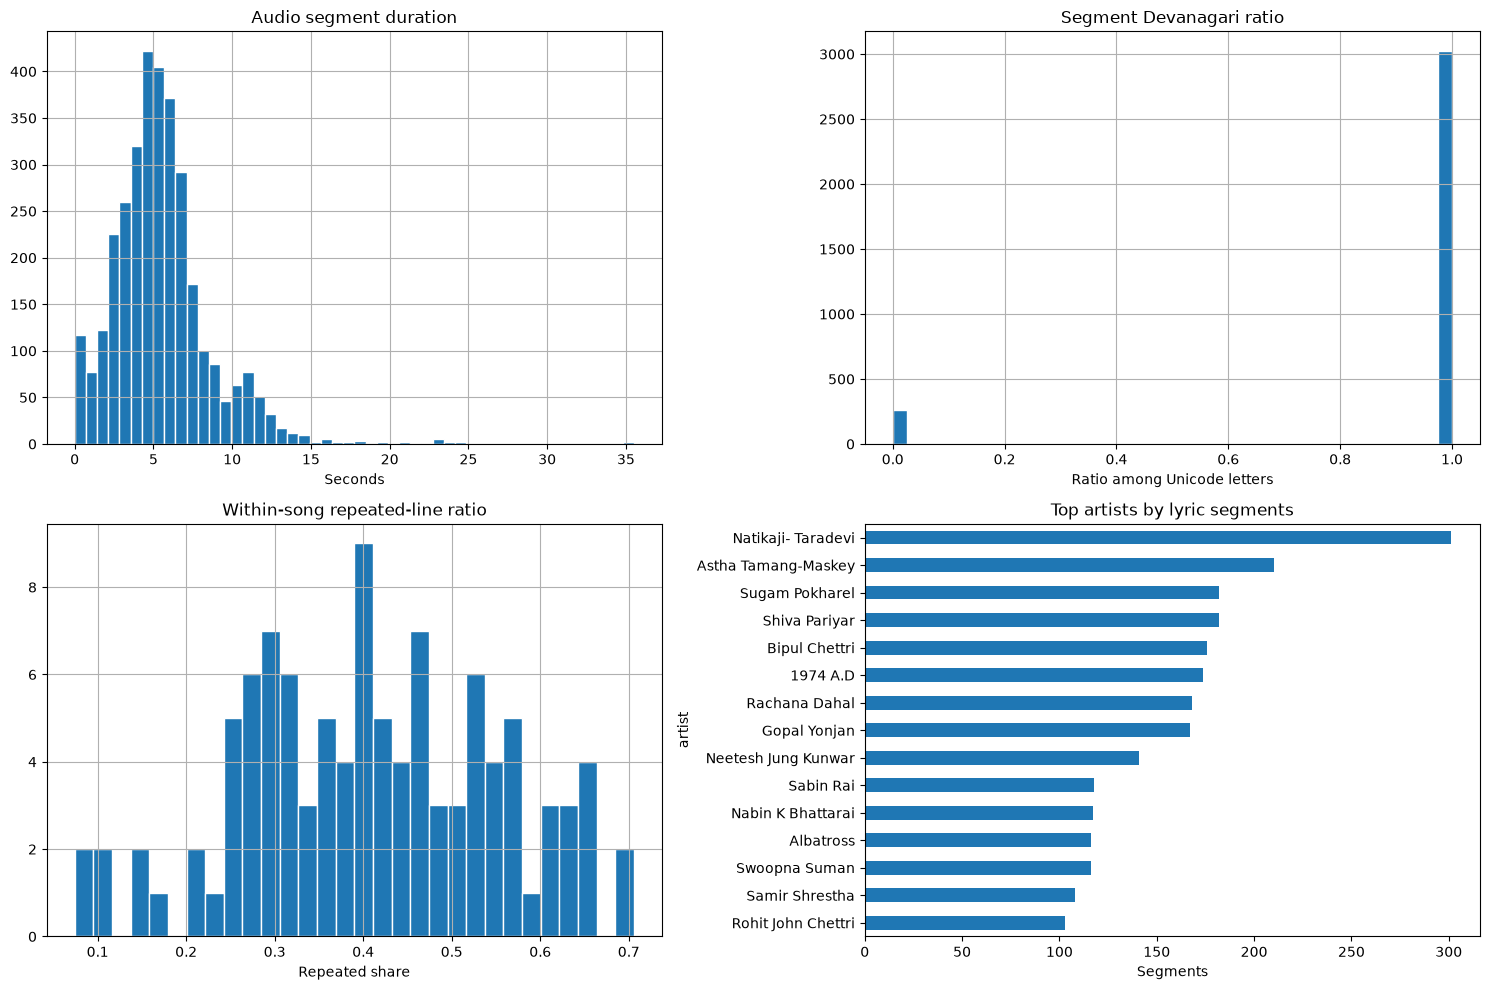

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
segments["duration_seconds"].hist(bins=50, ax=axes[0, 0], edgecolor="white")
axes[0, 0].set_title("Audio segment duration")
axes[0, 0].set_xlabel("Seconds")

segments["devanagari_ratio"].hist(bins=np.linspace(0, 1, 41), ax=axes[0, 1], edgecolor="white")
axes[0, 1].set_title("Segment Devanagari ratio")
axes[0, 1].set_xlabel("Ratio among Unicode letters")

songs["repetition_ratio"].hist(bins=30, ax=axes[1, 0], edgecolor="white")
axes[1, 0].set_title("Within-song repeated-line ratio")
axes[1, 0].set_xlabel("Repeated share")

top_artists = segments["artist"].value_counts().head(15).sort_values()
top_artists.plot.barh(ax=axes[1, 1])
axes[1, 1].set_title("Top artists by lyric segments")
axes[1, 1].set_xlabel("Segments")
plt.tight_layout()
plt.show()


In [8]:
print("Romanized/non-Devanagari examples:")
display(segments.loc[segments["devanagari_ratio"].lt(0.20), ["artist", "song", "Lyrics", "devanagari_ratio"]].sample(n=min(10, segments["devanagari_ratio"].lt(0.20).sum()), random_state=SEED))

print("Rows with missing audio (lyrics are still usable for text pretraining):")
display(segments.loc[~segments["audio_exists"], ["artist", "song", "segment_path", "Lyrics"]])

print("Songs with the highest repeated-line share:")
display(songs.sort_values(["repetition_ratio", "segment_count"], ascending=False).head(15))


Romanized/non-Devanagari examples:


,artist,song,Lyrics,devanagari_ratio
442,Anju Panta,Ghin Ghin Madal (Panche Baja),♪,0.0
2515,Sabin Rai,Akorinchhu,,0.0
2979,Sugam Pokharel,Pheri Tyo Din,♪,0.0
2580,Sabin Rai _ The Pharaoh,Samjhanchu,,0.0
2856,Shiva Pariyar,Fulai Fula Dinchhau ki - Remake Version,♪,0.0
3303,Yogeshwor Amatya,Bhanchhan Lognemanchhe,♪,0.0
2499,Sabin Rai,Akorinchhu,♪,0.0
2085,Rachana Dahal,Bhumari,"Yeah, yeah, oh-oh",0.0
218,Akash Khadka,Timi Bhayera,♪,0.0
2511,Sabin Rai,Akorinchhu,"Ah-ha, ha, ha, yeah, yeah, yeah, yeah",0.0


Rows with missing audio (lyrics are still usable for text pretraining):


,artist,song,segment_path,Lyrics
1384,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_3.wav,रात बित्यो हेर तिम्लाई सम्झेर
1387,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_6.wav,"ताराले गिज्जाइदियो, पागल ठानेर"
1391,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_10.wav,दिन ढल्यो हेर तिम्लाई कल्पेर
1392,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_11.wav,♪
1395,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_14.wav,"गुलाफले सोध्यो, ""उनी को हुन?"" भनेर"
1397,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_16.wav,"नहुनू टाढा प्रिय, ""को हो?"" भनेर"
1402,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_21.wav,दिन ढल्यो हेर तिम्लाई कल्पेर
1404,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_23.wav,दिन ढल्यो हेर तिम्लाई कल्पेर
1405,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_24.wav,रात बित्यो हेर तिम्लाई सम्झेर
1406,Nabin K Bhattarai,Raat Bityo,output/Raat Bityo/segment_25.wav,दिन ढल्यो हेर तिम्लाई कल्पेर


Songs with the highest repeated-line share:


,artist,song,text,segment_count,unique_line_count,repetition_ratio,duration_seconds,missing_audio_segments,devanagari_ratio,characters
93,Shiva Pariyar,Pilayo Sathile,पिउँदिन भन्दाभन्दै पिलायो साथीले\n♪\nपिउँदिन भ...,35,10,0.705882,278.528,0,1.0,1097
40,Karma Band,Kaha Hola Ghar,"कहाँ होला घरबार, कहाँ होला गाउँ?\nकहाँ होला घर...",32,10,0.687500,109.916,0,1.0,952
6,Adrian Pradhan,Hindda Hinddai,हिँड्दा हिँड्दै दोबाटोमा तिमी त कहाँ हराई दियौ...,30,10,0.655172,209.327,0,1.0,877
47,Nabin K Bhattarai,Yaad Sanchi-Samjhana,याद साँची कल्पी बस्छु\nछायाँ सँगै झस्किरहन्छु\...,27,9,0.653846,137.087,10,1.0,596
87,Sanjay Shrestha,Maya Meri Maya,"माया, मेरी माया, हाम्रो मिलन कहिले हुन्छ?\nमाय...",21,7,0.650000,193.566,0,1.0,743
2,1974 A.D,Gurans Fulyo,गुराँसै फूल्यो वनैमा\nमेरो मन झुल्यो तिम्रो मन...,28,10,0.642857,148.883,0,1.0,816
43,Nabin K Bhattarai,Aankhama,आँखामा तिमीलाई पाउँछु म धेरै-धेरै\nआँखामा तिमी...,20,7,0.631579,43.855,0,1.0,606
39,Harish Mathema,Ma Bhakta Hu Yo Desh,"म भक्त हुँ यो देशको, म रक्त हुँ यो देशको\nकहिल...",35,13,0.628571,218.673,0,1.0,1226
90,Shiva Pariyar,Fulai Fula Dinchhau ki - Remake Version,"फूलैफूल दिन्छौ कि, काँडैकाँडा दिन्छौ कि\nमायैम...",33,12,0.625000,235.033,0,1.0,1030
5,1974 A.D,Yo Mann Ta Mero Nepali Ho,"जसो गर, जे भन, जतासुकै लैजाऊ मलाई\nयो मन त मेर...",36,14,0.611111,203.415,0,1.0,973


## Pretraining interpretation

- Use the 38 artist-level `metadata.csv` files only; combining them with song tables doubles the same 3,310 rows.
- Use one document per song (105 documents), preserving line order and provenance.
- Use a lower song-level Devanagari gate before strict cleaning so mixed songs retain their Nepali portions; fully Romanized songs are excluded from the current Nepali-only corpus.
- Preserve chorus structure initially, but record repetition so lyrics can be down-weighted during training if necessary.
- Missing WAV files do not invalidate the corresponding lyric text for decoder pretraining.
- Keep artist and song only in provenance metadata, not embedded as synthetic prose in the training text.